<div align="center">

# Shapley meets Rawls – ESL Attribution Demo

## Census Income Dataset (UCI, Kohavi 1996)

This notebook reproduces the main empirical results from:
 
> *Shapley meets Rawls: an integrated framework for measuring and
> explaining unfairness.*  

**Convention:** the sensitive attribute (`sex`) is **always placed
last** in the feature matrix.  `group_column` defaults to the last
column index.

</div>

## 0 – Environment setup

In [1]:
import os
import warnings

# Silence TensorFlow INFO logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'


from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', message='.*default value of `dual`.*')
warnings.simplefilter('ignore', FutureWarning)

warnings.filterwarnings(
    "ignore",
    message=r".*functorch\.vmap is deprecated.*",
    category=FutureWarning,
    module=r"inFairness\.utils\.ndcg",
)


In [2]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import os
import glob
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.base import clone
from xgboost import XGBClassifier
from scipy.stats import loguniform
from aif360.datasets import BinaryLabelDataset
from torch import vmap
from aif360.algorithms.postprocessing import EqOddsPostprocessing
from aif360.metrics import ClassificationMetric
from joblib import dump


In [3]:
# Import the ESL attribution library 
import importlib
import LES as LES_module
import LES_Fair as LES_Fair_module
importlib.reload(LES_module)
importlib.reload(LES_Fair_module)
from LES import LES as LES  
from LES_Fair import LESfair 


In [4]:
import importlib
import plot_contributions
importlib.reload(plot_contributions)
import plot_contributions as ples

In [5]:
#%pip install ipython-autotime
%load_ext autotime


time: 67.4 μs (started: 2026-03-24 21:16:36 +01:00)


## 1 – Load and preprocess the Census Income dataset

In [6]:
from ucimlrepo import fetch_ucirepo

census_income = fetch_ucirepo(id=20)

census_income.data.targets['income'] = (
    census_income.data.targets['income'].str.strip().str.rstrip('.')
)
print('Unique income values:', census_income.data.targets['income'].unique())

Unique income values: <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str
time: 1min 51s (started: 2026-03-24 21:16:36 +01:00)


In [7]:

full_data = pd.concat(
    [census_income.data.features, census_income.data.targets], axis=1
)
full_data_clean = full_data.replace('?', np.nan).dropna()


full_data_clean['native-country'] = np.where(
    full_data_clean['native-country'] != 'United-States',
    'Non-United-States',
    full_data_clean['native-country'],
)
full_data_clean['race'] = np.where(
    full_data_clean['race'] != 'White', 'Non-white', full_data_clean['race']
)
for old, new in [
    ('Married-civ-spouse', 'married'),
    ('Married-spouse-absent', 'married'),
    ('Married-AF-spouse', 'married'),
    ('Never-married', 'never-married'),
    ('Divorced', 'other'),
    ('Separated', 'other'),
    ('Widowed', 'other'),
]:
    full_data_clean['marital-status'] = full_data_clean[
        'marital-status'
    ].replace(old, new)

full_data_clean.to_csv("full_data_clean.csv", index=False)


time: 328 ms (started: 2026-03-24 21:18:27 +01:00)


In [8]:
X = full_data_clean[
    ['age', 'education-num', 'hours-per-week', 'marital-status', 'sex']
]
y = full_data_clean['income'].str.strip().str.rstrip('.').map(
    {'<=50K': 0, '>50K': 1}
)
print(f'X shape: {X.shape},  y shape: {y.shape}')

X shape: (45222, 5),  y shape: (45222,)
time: 17.5 ms (started: 2026-03-24 21:18:28 +01:00)


In [9]:
# Encode categorical variables
le_marstat = LabelEncoder()
le_sex = LabelEncoder()
X = X.copy()
X['marital-status'] = le_marstat.fit_transform(X['marital-status'])
X['sex'] = le_sex.fit_transform(X['sex'])
y = LabelEncoder().fit_transform(y).ravel()

time: 17.8 ms (started: 2026-03-24 21:18:28 +01:00)


In [10]:
# Stratified train/test split (stratify on sex × income)
split = X['sex'].astype(str) + y.astype(str)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=split
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

# The sensitive attribute index is the LAST column
# (this is a general convention – works for any number of features)
gender_col_index = X_test.columns.get_loc('sex')  # = last column index
print('group_column =', gender_col_index, '(last column)')

column_names = X_train.columns.tolist()

group_column = 4 (last column)
time: 72.8 ms (started: 2026-03-24 21:18:28 +01:00)


## 2 – Train the classifier (Voting ensemble)

In [11]:
# Class imbalance: compute scale_pos_weight for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
class_weight = {0: 1, 1: scale_pos_weight}
print(f'scale_pos_weight = {scale_pos_weight:.2f}')

scale_pos_weight = 3.04
time: 823 μs (started: 2026-03-24 21:18:28 +01:00)


In [12]:
# XGBoost with random hyperparameter search
xgb = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=1)
param_dist_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [scale_pos_weight],
}
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    scoring='roc_auc', cv=5, n_jobs=-1, n_iter=10,
    verbose=1, random_state=42,
)
random_search_xgb.fit(X_train, y_train)
best_xgb = random_search_xgb.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
time: 21.7 s (started: 2026-03-24 21:18:28 +01:00)


In [13]:
# Decision tree with random hyperparameter search
dt = DecisionTreeClassifier(random_state=42, class_weight=class_weight)
param_dist_dt = {
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy'],
}
random_search_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist_dt,
    scoring='roc_auc', cv=5, n_jobs=-1, n_iter=10,
    verbose=1, random_state=42,
)
random_search_dt.fit(X_train, y_train)
best_dt = random_search_dt.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
time: 25 s (started: 2026-03-24 21:18:49 +01:00)


In [14]:
# LinearSVC calibrated for probability estimates
linear_svc = LinearSVC(
    random_state=42, dual=False, class_weight=class_weight, max_iter=1000
)
random_search_svc = RandomizedSearchCV(
    estimator=linear_svc,
    param_distributions={'C': loguniform(0.1, 100)},
    scoring='roc_auc', cv=5, n_jobs=-1, n_iter=5,
    verbose=1, random_state=42,
)
random_search_svc.fit(X_train, y_train)
best_linear_svc = random_search_svc.best_estimator_
calibrated_svc = CalibratedClassifierCV(best_linear_svc, cv=5)
calibrated_svc.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(C=n...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or 

time: 22.9 s (started: 2026-03-24 21:19:14 +01:00)


In [15]:
# Soft-voting ensemble
clf_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    random_state=42, n_jobs=1, min_samples_leaf=2, max_features='sqrt',
)
clf_lr = LogisticRegression(
    max_iter=1000, random_state=42, class_weight=class_weight
)
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('rf',  clf_rf),
        ('lr',  clf_lr),
        ('dt',  best_dt),
        ('svc', calibrated_svc),
    ],
    voting='soft', n_jobs=-1,
)
m = clone(voting_clf)
m = m.fit(X_train, y_train)

time: 14.5 s (started: 2026-03-24 21:19:37 +01:00)


In [16]:

dump(voting_clf, "voting_clf.joblib")

['voting_clf.joblib']

time: 12.5 ms (started: 2026-03-24 21:19:52 +01:00)


In [17]:
# Quick evaluation on the test set
y_pred = m.predict(X_test)
print(classification_report(y_test, y_pred))
print('Accuracy:', accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.78      0.85     10204
           1       0.55      0.81      0.66      3363

    accuracy                           0.79     13567
   macro avg       0.74      0.80      0.75     13567
weighted avg       0.83      0.79      0.80     13567

Accuracy: 0.7901525761037812
time: 478 ms (started: 2026-03-24 21:19:52 +01:00)


## 3 – Prepare numpy arrays for ESL attribution


In [18]:
# Full train / test arrays (sex is last column)
Xshp  = X_train.to_numpy()
yshp  = y_train.copy()
Xshpt = X_test.to_numpy()
yshpt = y_test.copy()

# Per-group subsets if needed
Xmen  = X_train[X_train['sex'] == 1].to_numpy()
Xwom  = X_train[X_train['sex'] == 0].to_numpy()
XmenT = X_test[X_test['sex'] == 1].to_numpy()
XwomT = X_test[X_test['sex'] == 0].to_numpy()

y_train_men = y_train[X_train['sex'] == 1]
y_train_wom = y_train[X_train['sex'] == 0]
y_test_men  = y_test[X_test['sex'] == 1]
y_test_wom  = y_test[X_test['sex'] == 0]

# Baseline: average TPR of a random classifier (≈ 0.5)
def random_guessing_classifier(y_true, p=0.5, seed=None):
    np.random.seed(seed)
    y_pred = np.random.choice([0, 1], size=len(y_true), p=[1 - p, p])
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0

tprR = np.mean([
    random_guessing_classifier(y_test, p=0.5, seed=i)
    for i in range(1000)
])
print(f'Average random TPR (base) = {tprR:.3f}')

# Overall model TPR
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
tpr = tp / (tp + fn)
print(f'Model TPR on test set = {tpr:.4f}')

# Positive counts per group (for asymptotic tests)
n1 = int(np.sum(y_test_men == 1))
n2 = int(np.sum(y_test_wom == 1))
print(f'n_pos men = {n1},  n_pos women = {n2}')

Average random TPR (base) = 0.500
Model TPR on test set = 0.8058
n_pos men = 2862,  n_pos women = 501
time: 2.28 s (started: 2026-03-24 21:19:52 +01:00)


In [19]:
np.save("Xshp.npy",  Xshp)
np.save("yshp.npy",  yshp)
np.save("Xshpt.npy", Xshpt)
np.save("yshpt.npy", yshpt)
np.save("gender_idx.npy", np.array([gender_col_index]))

time: 27.7 ms (started: 2026-03-24 21:19:55 +01:00)


## 4 – Fairness audit (AIF360)

In [20]:
# Build AIF360 datasets for the baseline model
y_test_df = pd.DataFrame(y_test, columns=['income'])
ground_truth_dataset = BinaryLabelDataset(
    df=pd.concat(
        [X_test.reset_index(drop=True), y_test_df.reset_index(drop=True)],
        axis=1,
    ),
    label_names=['income'],
    protected_attribute_names=['sex'],
)
predicted_dataset = ground_truth_dataset.copy(deepcopy=True)
predicted_dataset.labels = y_pred.reshape(-1, 1)

privileged_groups   = [{'sex': 1}]   # Male
unprivileged_groups = [{'sex': 0}]   # Female

cm = ClassificationMetric(
    ground_truth_dataset, predicted_dataset,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
)
print('Statistical parity difference :', cm.statistical_parity_difference())
print('Equal opportunity difference  :', cm.equal_opportunity_difference())
print('Average odds difference       :', cm.average_odds_difference())

Statistical parity difference : -0.3523664915184951
Equal opportunity difference  : -0.24092067437452136
Average odds difference       : -0.2441025515743258
time: 25.6 ms (started: 2026-03-24 21:19:55 +01:00)


## 5 – First-stage ESL group attribution

Five ESL values are computed for the two groups (Men / Women).  

In [21]:
# Instantiate one LES object per ESL value
attribution     = LES(model=m, method='shapley')
attributionES   = LES(model=m, method='ES_LES')
attributionSol  = LES(model=m, method='solidarity')
attributionCs   = LES(model=m, method='consensus')
attributionLSP  = LES(model=m, method='LSP')
attributionESLin= LES(model=m, method='ES')

time: 463 μs (started: 2026-03-24 21:19:55 +01:00)


In [22]:
# --- Shapley ---
results_level1 = attribution.fit_FS(
    Xshp, yshp, Xshpt, yshpt
)
print('Shapley:', results_level1)

Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.2015968063872275, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.6834381551362687, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(0),), Group: 1, v_s: 1.2015968063872275, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(1),), Group: 0, v_s: 1.6834381551362687, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Shapley: [[0.56490746 1.0467488 ]]
time: 1min 1s (started: 2026-03-24 21:19:55 +01:00)


In [23]:
# --- ES_LES (powerset) ---
resultses_level1 = attributionES.fit_FS(Xshp, yshp, Xshpt, yshpt)
print('ES_LES:', resultses_level1)

Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.2015968063872275, coeff: 0.5, bi:0, b_si:1
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.6834381551362687, coeff: 0.5, bi:0, b_si:1
Coalition: (np.int64(0),), Group: 1, v_s: 1.2015968063872275, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1, b_si:1
Coalition: (np.int64(1),), Group: 0, v_s: 1.6834381551362687, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1, b_si:1
ES_LES: [[0.56490746 1.0467488 ]]
time: 1min 25s (started: 2026-03-24 21:20:56 +01:00)


In [24]:
# --- ES (closed-form) ---
resultsesLin_level1 = attributionESLin.fit_FS(Xshp, yshp, Xshpt, yshpt)
print('ES (closed-form):', resultsesLin_level1)

ES (closed-form): [0.56490746 1.0467488 ]
time: 16.2 s (started: 2026-03-24 21:22:21 +01:00)


In [25]:
# --- Solidarity ---
resultsol_level1 = attributionSol.fit_FS(Xshp, yshp, Xshpt, yshpt)
print('Solidarity:', resultsol_level1)

Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.2015968063872275, coeff: 0.5, bi:0, b_si:0.5
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.6834381551362687, coeff: 0.5, bi:0, b_si:0.5
Coalition: (np.int64(0),), Group: 1, v_s: 1.2015968063872275, v_s_i: 1.6116562592922967, coeff: 0.5, bi:0.5, b_si:1
Coalition: (np.int64(1),), Group: 0, v_s: 1.6834381551362687, v_s_i: 1.6116562592922967, coeff: 0.5, bi:0.5, b_si:1
Solidarity: [[0.68536779 0.92628847]]
time: 42.8 s (started: 2026-03-24 21:22:37 +01:00)


In [26]:
# --- Consensus ---
resultscs_level1 = attributionCs.fit_FS(Xshp, yshp, Xshpt, yshpt)
print('Consensus:', resultscs_level1)

Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.2015968063872275, coeff: 0.5, bi:0, b_si:1.0
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.6834381551362687, coeff: 0.5, bi:0, b_si:1.0
Coalition: (np.int64(0),), Group: 1, v_s: 1.2015968063872275, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1.0, b_si:1
Coalition: (np.int64(1),), Group: 0, v_s: 1.6834381551362687, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1.0, b_si:1
Consensus: [[0.56490746 1.0467488 ]]
time: 43 s (started: 2026-03-24 21:23:20 +01:00)


In [27]:
# --- LSP ---
resultsLSp_level1 = attributionLSP.fit_FS(Xshp, yshp, Xshpt, yshpt)
print('LSP:', resultsLSp_level1)

Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.2015968063872275, coeff: 0.5, bi:0, b_si:1.0
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.6834381551362687, coeff: 0.5, bi:0, b_si:1.0
Coalition: (np.int64(0),), Group: 1, v_s: 1.2015968063872275, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1.0, b_si:1
Coalition: (np.int64(1),), Group: 0, v_s: 1.6834381551362687, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1.0, b_si:1
LSP: [[0.56490746 1.0467488 ]]
time: 42.8 s (started: 2026-03-24 21:24:03 +01:00)


In [28]:
phi_dict = {
    "Shapley": np.asarray(results_level1).ravel(),
    "ES": np.asarray(resultses_level1).ravel(),
    "Solidarity": np.asarray(resultsol_level1).ravel(),
    "Consensus": np.asarray(resultscs_level1).ravel(),
    "LSP": np.asarray(resultsLSp_level1).ravel()
}

time: 452 μs (started: 2026-03-24 21:24:46 +01:00)


In [29]:
phi_dict

{'Shapley': array([0.56490746, 1.0467488 ]),
 'ES': array([0.56490746, 1.0467488 ]),
 'Solidarity': array([0.68536779, 0.92628847]),
 'Consensus': array([0.56490746, 1.0467488 ]),
 'LSP': array([0.56490746, 1.0467488 ])}

time: 7.15 ms (started: 2026-03-24 21:24:46 +01:00)


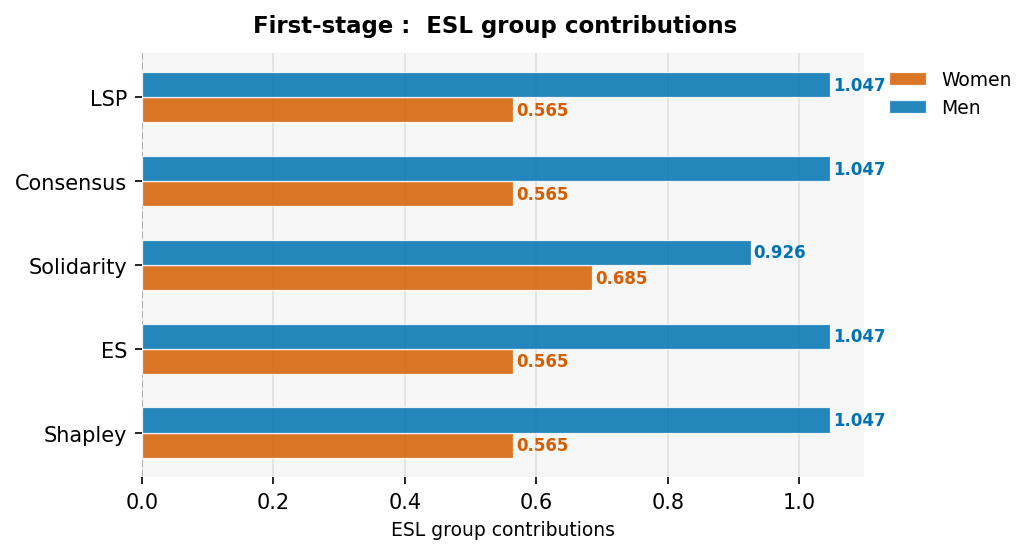

time: 437 ms (started: 2026-03-24 21:24:46 +01:00)


In [30]:
fig, ax = ples.les_group_bar(
    phi_dict,
    group_labels=["Women", "Men"]
)
fig.savefig("group contribution", dpi=300, bbox_inches="tight")
plt.show()

## 6 – Group-level fairness test (Theorem 4.2)

In [31]:
# Asymptotic Z-test: H0: phi_men - phi_women =0
# p and n1, n2 defined in Section 3
p = tpr
ES_test = LES.fairness_test(
    1, 1,
    resultses_level1[0, 1],  # men
    resultses_level1[0, 0],  # women
    p, n1, n2, alpha=0.05,
)

sol_test = LES.fairness_test(
    1, 1,
    resultsol_level1[0, 1],
    resultsol_level1[0, 0],
    p, n1, n2, alpha=0.05,
)



time: 1.25 ms (started: 2026-03-24 21:24:47 +01:00)


In [32]:
table1 = pd.DataFrame([
    {
        "Metric": "ES",
        "D": ES_test["D"],
        "Z": ES_test["Z"],
        "p_value": ES_test["p_value"],
        "CI_lower": ES_test["confidence_interval"][0],
        "CI_upper": ES_test["confidence_interval"][1],
    },
    {
        "Metric": "Solidarity",
        "D": sol_test["D"],
        "Z": sol_test["Z"],
        "p_value": sol_test["p_value"],
        "CI_lower": sol_test["confidence_interval"][0],
        "CI_upper": sol_test["confidence_interval"][1],
    }
])

print(table1)

       Metric         D          Z       p_value  CI_lower  CI_upper
0          ES  0.481841  12.576215  0.000000e+00  0.406748  0.556935
1  Solidarity  0.240921   6.288107  3.213596e-10  0.165827  0.316014
time: 11.1 ms (started: 2026-03-24 21:24:47 +01:00)


## Second-stage ESL feature attribution (with parallelism)

In [33]:
# Instantiate parallelised second-stage objects
attributionSecdp  = LES(model=voting_clf, method='shapleysecd_parallel')
attributionSecdp1 = LES(model=voting_clf, method='ESsecond_parallel')
attributionSecdp2 = LES(model=voting_clf, method='solidaritysecond_parallel')
attributionSecdp3 = LES(model=voting_clf, method='consensussecond_parallel')
attributionSecdp4 = LES(model=voting_clf, method='LSPsecond_parallel')

time: 806 μs (started: 2026-03-24 21:24:47 +01:00)


In [34]:
# resp[0] = women contributions, resp[1] = men contributions
# shape of each: (n_features,)
resp = attributionSecdp.fit_parallel(
    Xshp, yshp, Xshpt, yshpt, n_jobs=56
)
print('Shapley:', resp)

Coalition: (), Group: 0, v_s: 0.0, v_s_i: 0.5868263473053874, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.608665269042628, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(0),), Group: 1, v_s: 0.5868263473053874, v_s_i: 1.4564377044305665, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(1),), Group: 0, v_s: 1.608665269042628, v_s_i: 1.4564377044305665, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.2015968063872275, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.6834381551362687, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(0),), Group: 1, v_s: 1.2015968063872275, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(1),), Group: 0, v_s: 1.6834381551362687, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 0.5668662674650681, coeff: 0

In [35]:
resp1 = attributionSecdp1.fit_parallel(
    Xshp, yshp, Xshpt, yshpt, n_jobs=32
)
print('ES:', resp1)

Coalition: (), Group: 0, v_s: 0.0, v_s_i: 0.598802395209579, coeff: 0.5, bi:0, b_si:1
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.424877707896576, coeff: 0.5, bi:0, b_si:1
Coalition: (np.int64(0),), Group: 1, v_s: 0.598802395209579, v_s_i: 1.3018138566755861, coeff: 0.5, bi:1, b_si:1
Coalition: (np.int64(1),), Group: 0, v_s: 1.424877707896576, v_s_i: 1.3018138566755861, coeff: 0.5, bi:1, b_si:1
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 0.5868263473053874, coeff: 0.5, bi:0, b_si:1
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.608665269042628, coeff: 0.5, bi:0, b_si:1
Coalition: (np.int64(0),), Group: 1, v_s: 0.5868263473053874, v_s_i: 1.4564377044305665, coeff: 0.5, bi:1, b_si:1
Coalition: (np.int64(1),), Group: 0, v_s: 1.608665269042628, v_s_i: 1.4564377044305665, coeff: 0.5, bi:1, b_si:1
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.077844311377247, coeff: 0.5, bi:0, b_si:1
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.7714884696016777, coeff: 0.5, bi:0, b_si:1
Coalition: (np.int64(0),), Gr

In [36]:
resp2 = attributionSecdp2.fit_parallel(
    Xshp, yshp, Xshpt, yshpt, n_jobs=32
)
print('Solidarity:', resp2)

Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.077844311377247, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.7714884696016777, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(0),), Group: 1, v_s: 1.077844311377247, v_s_i: 1.6681534344335394, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(1),), Group: 0, v_s: 1.7714884696016777, v_s_i: 1.6681534344335394, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.2015968063872275, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.6834381551362687, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(0),), Group: 1, v_s: 1.2015968063872275, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(1),), Group: 0, v_s: 1.6834381551362687, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 0.5668662674650681, coeff: 0

In [37]:
resp3 = attributionSecdp3.fit_parallel(
    Xshp, yshp, Xshpt, yshpt, n_jobs=32
)
print('Consensus:', resp3)

Coalition: (), Group: 0, v_s: 0.0, v_s_i: 0.5868263473053874, coeff: 0.5, bi:0, b_si:1
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.608665269042628, coeff: 0.5, bi:0, b_si:1
Coalition: (np.int64(0),), Group: 1, v_s: 0.5868263473053874, v_s_i: 1.4564377044305665, coeff: 0.5, bi:1, b_si:1
Coalition: (np.int64(1),), Group: 0, v_s: 1.608665269042628, v_s_i: 1.4564377044305665, coeff: 0.5, bi:1, b_si:1
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.2015968063872275, coeff: 0.5, bi:0, b_si:1
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.6834381551362687, coeff: 0.5, bi:0, b_si:1
Coalition: (np.int64(0),), Group: 1, v_s: 1.2015968063872275, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1, b_si:1
Coalition: (np.int64(1),), Group: 0, v_s: 1.6834381551362687, v_s_i: 1.6116562592922967, coeff: 0.5, bi:1, b_si:1
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 0.5668662674650681, coeff: 0.5, bi:0, b_si:1.0
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.6051712089447943, coeff: 0.5, bi:0, b_si:1.0
Coalition: (np.int64

In [38]:
resp4 = attributionSecdp4.fit_parallel(
    Xshp, yshp, Xshpt, yshpt, n_jobs=32
)
print('LSP:', resp4)

Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.1257485029940135, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.8008385744234803, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(0),), Group: 1, v_s: 1.1257485029940135, v_s_i: 1.7002676181980352, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(1),), Group: 0, v_s: 1.8008385744234803, v_s_i: 1.7002676181980352, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.1896207584830358, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.6939203354297698, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(0),), Group: 1, v_s: 1.1896207584830358, v_s_i: 1.6187927445732957, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(1),), Group: 0, v_s: 1.6939203354297698, v_s_i: 1.6187927445732957, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.077844311377247, coeff: 

In [39]:
contrib_women_dict = {
    "Shapley": np.asarray(resp[0]).ravel(),
    "ES": np.asarray(resp1[0]).ravel(),
    "Solidarity": np.asarray(resp2[0]).ravel(),
    "Consensus": np.asarray(resp3[0]).ravel(),
    "LSP": np.asarray(resp4[0]).ravel(),
}

contrib_men_dict = {
    "Shapley": np.asarray(resp[1]).ravel(),
    "ES": np.asarray(resp1[1]).ravel(),
    "Solidarity": np.asarray(resp2[1]).ravel(),
    "Consensus": np.asarray(resp3[1]).ravel(),
    "LSP": np.asarray(resp4[1]).ravel(),
}

time: 674 μs (started: 2026-03-24 21:35:33 +01:00)


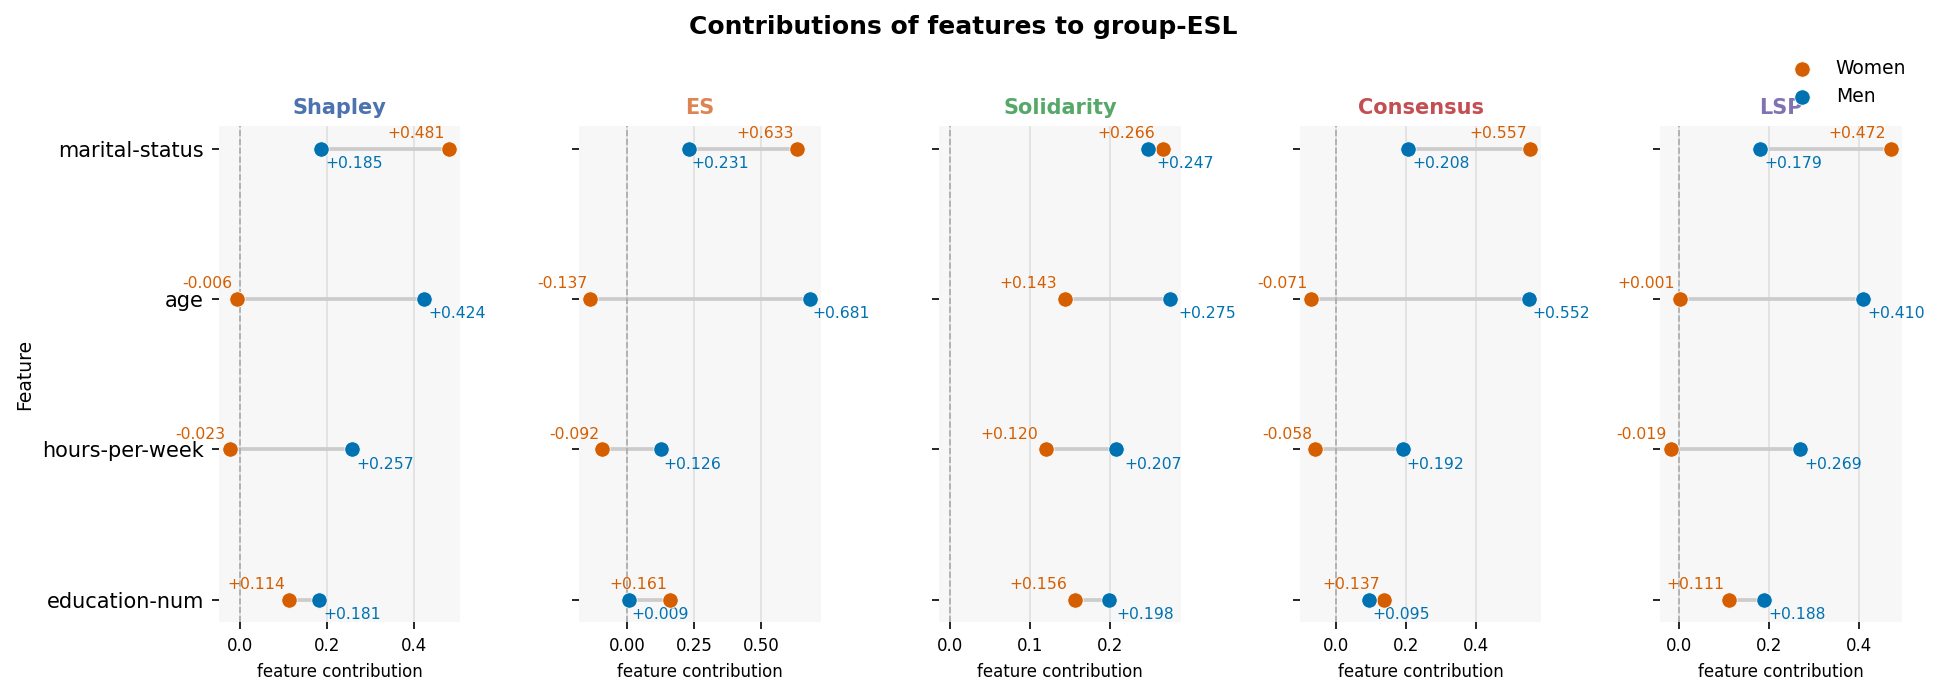

time: 1.16 s (started: 2026-03-24 21:35:33 +01:00)


In [40]:
feature_names = column_names[:gender_col_index] 
fig, axes = ples.les_summary_dot(
    contrib_women_dict,
    contrib_men_dict,
    feature_names,
    group_labels=["Women", "Men"]
)
fig.savefig("feature contribution", dpi=300, bbox_inches="tight")
plt.show()


## 9 – Asymptotic variance and feature-level tests

(see Proposition B.2).

| Method | Description |
|--------|-------------|
| `VAR_par`   | Main formula (Proposition B.2) |
| `Variance_simple_H` | Men variance  formula |
| `Variance_simple_F` | Women variance formula |

In [41]:
Variance        = LES(model=m, method='VAR_par')
Variance_simple_H = LES(model=m, method='VAR_par_1')
Variance_simple_F = LES(model=m, method='VAR_par_2')

time: 385 μs (started: 2026-03-24 21:35:34 +01:00)


In [42]:
variance_par_zero = Variance_simple_H.VAR_par_1(
    Xshp, Xwom, Xmen,
    yshp, y_train_wom, y_train_men,
    Xshpt, XwomT, XmenT,
    yshpt, y_test_wom, y_test_men,
    n_jobs=56, base_seed=123, metric='TPR',
)



Coalition: (), Group: 0, v_s: 0.0, v_s_i: 0.598802395209579, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.424877707896576, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(0),), Group: 1, v_s: 0.598802395209579, v_s_i: 1.3018138566755861, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(1),), Group: 0, v_s: 1.424877707896576, v_s_i: 1.3018138566755861, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 0.5868263473053874, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.608665269042628, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(0),), Group: 1, v_s: 0.5868263473053874, v_s_i: 1.4564377044305665, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (np.int64(1),), Group: 0, v_s: 1.608665269042628, v_s_i: 1.4564377044305665, coeff: 0.5, bi:1, b_si:1, TPR_random:0.5
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 1.077844311377247, coeff: 0.5, b

In [43]:
print(variance_par_zero)

(array([[0.00043582, 0.0008564 , 0.00038975, 0.00145157]]), array([[0.00113259, 0.00259921, 0.00127019, 0.00276345]]), array([[8.22366778e-05, 1.01796490e-04, 7.50894455e-05, 1.24401091e-04]]), array([[0.00058522, 0.00140113, 0.00060604, 0.00181008]]), array([[0.0004695 , 0.00082709, 0.00042367, 0.00142025]]))
time: 916 μs (started: 2026-03-24 21:44:11 +01:00)


In [44]:
# Feature tests: H0: C^k_men = 0  
print('--- Feature-level tests (all ESL values,H0: C^k_men = 0 ---')

esl_names = ['Shapley', 'ES_LES', 'Solidarity', 'Consensus', 'LSP']
resp_list  = [resp, resp1, resp2, resp3, resp4]

rows = []

for esl_idx, (ename, respi) in enumerate(zip(esl_names, resp_list)):
    for k, fname in enumerate(feature_names):
        t = LES.feature_test(
            respi[1][k],            
            0,            
            variance_par_zero[esl_idx][0][k],
            0.05,
        )

        rows.append({
            "ESL": ename,
            "Feature": fname,
            "D": t["D"],
            "Z": t["Z"],
            "p_value": t["p_value"],
            "CI_lower": t["confidence_interval"][0],
            "CI_upper": t["confidence_interval"][1],
        })

df_feature_tests_h = pd.DataFrame(rows)
print(df_feature_tests_h.to_string(index=False))




--- Feature-level tests (all ESL values,H0: C^k_men = 0 ---
       ESL        Feature        D         Z      p_value  CI_lower  CI_upper
   Shapley            age 0.423569 20.289399 0.000000e+00  0.382652  0.464485
   Shapley  education-num 0.180843  6.179664 6.423808e-10  0.123486  0.238200
   Shapley hours-per-week 0.257270 13.031579 0.000000e+00  0.218576  0.295964
   Shapley marital-status 0.185067  4.857473 1.188935e-06  0.110393  0.259741
    ES_LES            age 0.680587 20.223068 0.000000e+00  0.614627  0.746548
    ES_LES  education-num 0.008744  0.171506 8.638257e-01 -0.091180  0.108668
    ES_LES hours-per-week 0.126314  3.544202 3.938027e-04  0.056462  0.196167
    ES_LES marital-status 0.231103  4.396230 1.101471e-05  0.128071  0.334136
Solidarity            age 0.274524 30.272490 0.000000e+00  0.256751  0.292298
Solidarity  education-num 0.197926 19.617163 0.000000e+00  0.178151  0.217701
Solidarity hours-per-week 0.207043 23.893072 0.000000e+00  0.190060  0.224027
Soli

In [45]:
variance_par_zero2 = Variance_simple_F.VAR_par_2(
    Xshp, Xwom, Xmen,
    yshp, y_train_wom, y_train_men,
    Xshpt, XwomT, XmenT,
    yshpt, y_test_wom, y_test_men,
    n_jobs=56, base_seed=123, metric='TPR',
)

Coalition: (), Group: 0, v_s: 0.0, v_s_i: 0.0039920159680638485, coeff: 0.5, bi:0, b_si:1
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.6540880503144657, coeff: 0.5, bi:0, b_si:1
Coalition: (np.int64(0),), Group: 1, v_s: 0.0039920159680638485, v_s_i: 1.4082664287838227, coeff: 0.5, bi:1, b_si:1
Coalition: (np.int64(1),), Group: 0, v_s: 1.6540880503144657, v_s_i: 1.4082664287838227, coeff: 0.5, bi:1, b_si:1
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 0.5668662674650681, coeff: 0.5, bi:0, b_si:1
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.6051712089447943, coeff: 0.5, bi:0, b_si:1
Coalition: (np.int64(0),), Group: 1, v_s: 0.5668662674650681, v_s_i: 1.4504906333630674, coeff: 0.5, bi:1, b_si:1
Coalition: (np.int64(1),), Group: 0, v_s: 1.6051712089447943, v_s_i: 1.4504906333630674, coeff: 0.5, bi:1, b_si:1
Coalition: (), Group: 0, v_s: 0.0, v_s_i: 0.18762475049900054, coeff: 0.5, bi:0, b_si:1
Coalition: (), Group: 1, v_s: 0.0, v_s_i: 1.6995108315863037, coeff: 0.5, bi:0, b_si:1
Coalition: (np.

In [46]:
print(variance_par_zero2)

(array([[0.0002351 , 0.00079128, 0.00027083, 0.00178247]]), array([[0.00107047, 0.00261563, 0.00124435, 0.00288491]]), array([[5.96794031e-05, 9.10020807e-05, 6.07955279e-05, 1.60133021e-04]]), array([[0.00044902, 0.00138636, 0.00053129, 0.0020484 ]]), array([[0.00028591, 0.00078066, 0.00031769, 0.00174294]]))
time: 1.03 ms (started: 2026-03-24 21:52:28 +01:00)


In [47]:
# Feature tests: H0: C^k_women= 0  
print('--- Feature-level tests (all ESL values,H0: C_k_women = 0  ---')

esl_names = ['Shapley', 'ES_LES', 'Solidarity', 'Consensus', 'LSP']
resp_list  = [resp, resp1, resp2, resp3, resp4]

rows = []

for esl_idx, (ename, respi) in enumerate(zip(esl_names, resp_list)):
    for k, fname in enumerate(feature_names):
        t = LES.feature_test(
            respi[0][k],            
            0,            
            variance_par_zero2[esl_idx][0][k],
            0.05,
        )

        rows.append({
            "ESL": ename,
            "Feature": fname,
            "D": t["D"],
            "Z": t["Z"],
            "p_value": t["p_value"],
            "CI_lower": t["confidence_interval"][0],
            "CI_upper": t["confidence_interval"][1],
        })

df_feature_tests_f = pd.DataFrame(rows)
print(df_feature_tests_f.to_string(index=False))




--- Feature-level tests (all ESL values,H0: C_k_women = 0  ---
       ESL        Feature         D         Z  p_value  CI_lower  CI_upper
   Shapley            age -0.006233 -0.406503 0.684373 -0.036285  0.023819
   Shapley  education-num  0.113586  4.037963 0.000054  0.058453  0.168719
   Shapley hours-per-week -0.023401 -1.421974 0.155034 -0.055656  0.008854
   Shapley marital-status  0.480955 11.391845 0.000000  0.398207  0.563704
    ES_LES            age -0.136728 -4.178968 0.000029 -0.200854 -0.072602
    ES_LES  education-num  0.161045  3.148901 0.001639  0.060806  0.261284
    ES_LES hours-per-week -0.092119 -2.611419 0.009017 -0.161257 -0.022980
    ES_LES marital-status  0.632709 11.779787 0.000000  0.527436  0.737981
Solidarity            age  0.143423 18.565439 0.000000  0.128281  0.158564
Solidarity  education-num  0.155941 16.346909 0.000000  0.137244  0.174638
Solidarity hours-per-week  0.120062 15.398193 0.000000  0.104780  0.135344
Solidarity marital-status  0.265942 2

In [48]:
# Main variance formula (VAR_par)
variance_par = Variance.VAR_par(
    Xshp, Xwom, Xmen,
    yshp, y_train_wom, y_train_men,
    Xshpt, XwomT, XmenT,
    yshpt, y_test_wom, y_test_men,
    n_jobs=56, base_seed=423, metric='TPR',
)

time: 8min 18s (started: 2026-03-24 21:52:28 +01:00)


In [49]:
print(variance_par)

(array([[0.00104424, 0.00270506, 0.00105111, 0.00536817]]), array([[0.00318972, 0.0088978 , 0.00367306, 0.01003252]]), array([[0.00018072, 0.0002616 , 0.00017756, 0.0004154 ]]), array([[0.00145242, 0.00464947, 0.00163143, 0.0065854 ]]), array([[0.00124325, 0.00266594, 0.00124816, 0.0052184 ]]))
time: 962 μs (started: 2026-03-24 22:00:46 +01:00)


In [50]:
# Feature tests: H0: C^k_men = C^k_women  (main formula)
print('--- Feature-level tests (all ESL values,---')

esl_names = ['Shapley', 'ES_LES', 'Solidarity', 'Consensus', 'LSP']
resp_list  = [resp, resp1, resp2, resp3, resp4]

rows = []

for esl_idx, (ename, respi) in enumerate(zip(esl_names, resp_list)):
    for k, fname in enumerate(feature_names):
        t = LES.feature_test(
            respi[1][k],            # men
            respi[0][k],            # women
            variance_par[esl_idx][0][k],
            0.05,
        )

        rows.append({
            "ESL": ename,
            "Feature": fname,
            "D": t["D"],
            "Z": t["Z"],
            "p_value": t["p_value"],
            "CI_lower": t["confidence_interval"][0],
            "CI_upper": t["confidence_interval"][1],
        })

df_feature_tests = pd.DataFrame(rows)
print(df_feature_tests.to_string(index=False))


--- Feature-level tests (all ESL values,---
       ESL        Feature         D         Z      p_value  CI_lower  CI_upper
   Shapley            age  0.429801 13.300475 0.000000e+00  0.366466  0.493137
   Shapley  education-num  0.067257  1.293147 1.959602e-01 -0.034681  0.169195
   Shapley hours-per-week  0.280671  8.657151 0.000000e+00  0.217128  0.344215
   Shapley marital-status -0.295888 -4.038449 5.380572e-05 -0.439491 -0.152286
    ES_LES            age  0.817315 14.471488 0.000000e+00  0.706621  0.928009
    ES_LES  education-num -0.152301 -1.614590 1.063996e-01 -0.337181  0.032579
    ES_LES hours-per-week  0.218433  3.604165 3.131576e-04  0.099648  0.337218
    ES_LES marital-status -0.401606 -4.009541 6.083687e-05 -0.597920 -0.205291
Solidarity            age  0.131102  9.752311 0.000000e+00  0.104754  0.157450
Solidarity  education-num  0.041985  2.595806 9.436943e-03  0.010284  0.073685
Solidarity hours-per-week  0.086981  6.527688 6.679279e-11  0.060865  0.113098
Solidari

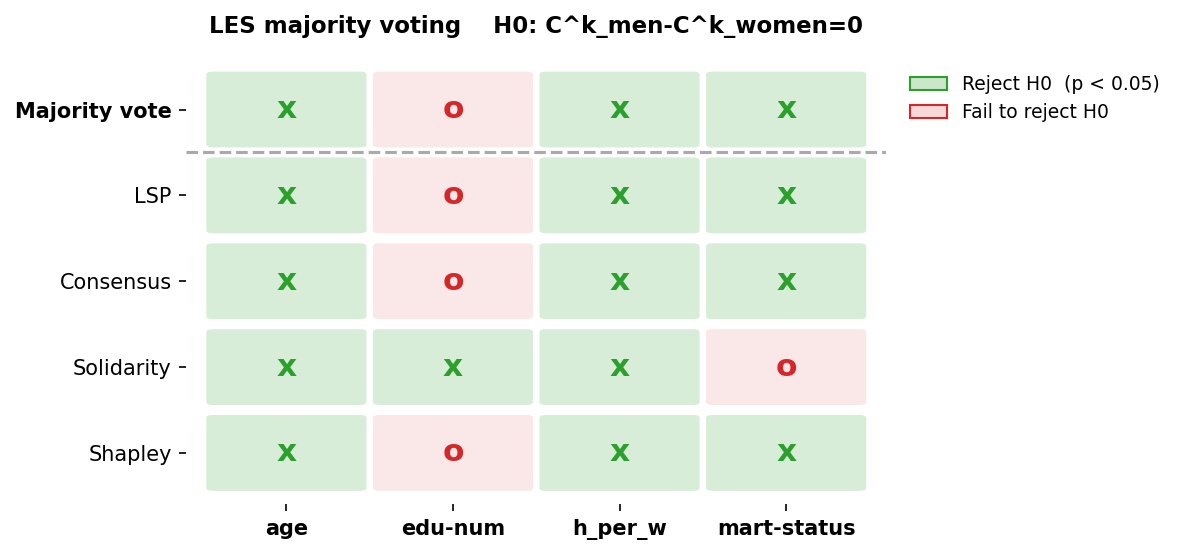

time: 489 ms (started: 2026-03-24 22:00:46 +01:00)


In [51]:
test_results = {}

for ename in df_feature_tests["ESL"].unique():
    sub = df_feature_tests[df_feature_tests["ESL"] == ename]
    test_results[ename] = []

    for _, row in sub.iterrows():
        test_results[ename].append({
            "D": row["D"],
            "Z": row["Z"],
            "p_value": row["p_value"],
            "confidence_interval": (row["CI_lower"], row["CI_upper"]),
        })

feature_name = ["age", "edu-num", "h_per_w", "mart-status"]

fig, ax = ples.les_majority_voting(
    test_results,
    feature_name,
    alpha=0.05,
)

fig.savefig("majority_voting.png", dpi=400, bbox_inches="tight")
plt.show()

In [52]:
##  – Bootstrap tests

time: 172 μs (started: 2026-03-24 22:00:47 +01:00)


In [53]:
data_dir = os.path.join("bootstrap_diffs")
files = sorted(glob.glob(os.path.join(data_dir, "diff_*.npy")))

diffs = np.stack([np.load(f) for f in files], axis=0)

print("Feat  mean    2.5%     97.5%")
for i in range(diffs.shape[1]):
    d = diffs[:, i]
    lo, hi = np.percentile(d, [2.5, 97.5])
    mu = d.mean()
    print(f"{i:>4d}  {mu:6.3f}  {lo:6.3f}  {hi:6.3f}")

Feat  mean    2.5%     97.5%
   0   0.430   0.399   0.459
   1   0.067   0.012   0.125
   2   0.281   0.251   0.312
   3  -0.294  -0.377  -0.210
time: 882 ms (started: 2026-03-24 22:00:47 +01:00)


In [54]:
data_dir = os.path.join("bootstrap_diffs_es")
files = sorted(glob.glob(os.path.join(data_dir, "diff_*.npy")))

diffs = np.stack([np.load(f) for f in files], axis=0)

print("Feat  mean    2.5%     97.5%")
for i in range(diffs.shape[1]):
    d = diffs[:, i]
    lo, hi = np.percentile(d, [2.5, 97.5])
    mu = d.mean()
    print(f"{i:>4d}  {mu:6.3f}  {lo:6.3f}  {hi:6.3f}")

Feat  mean    2.5%     97.5%
   0   0.818   0.784   0.851
   1  -0.152  -0.218  -0.086
   2   0.218   0.181   0.255
   3  -0.400  -0.476  -0.314
time: 886 ms (started: 2026-03-24 22:00:48 +01:00)


In [55]:
data_dir = os.path.join("bootstrap_diffs_sol")
files = sorted(glob.glob(os.path.join(data_dir, "diff_*.npy")))

diffs = np.stack([np.load(f) for f in files], axis=0)

print("Feat  mean    2.5%     97.5%")
for i in range(diffs.shape[1]):
    d = diffs[:, i]
    lo, hi = np.percentile(d, [2.5, 97.5])
    mu = d.mean()
    print(f"{i:>4d}  {mu:6.3f}  {lo:6.3f}  {hi:6.3f}")

Feat  mean    2.5%     97.5%
   0   0.131   0.121   0.141
   1   0.042   0.028   0.056
   2   0.087   0.077   0.097
   3  -0.019  -0.039   0.003
time: 885 ms (started: 2026-03-24 22:00:49 +01:00)


In [56]:
data_dir = os.path.join("bootstrap_diffs_cons")
files = sorted(glob.glob(os.path.join(data_dir, "diff_*.npy")))

diffs = np.stack([np.load(f) for f in files], axis=0)

print("Feat  mean    2.5%     97.5%")
for i in range(diffs.shape[1]):
    d = diffs[:, i]
    lo, hi = np.percentile(d, [2.5, 97.5])
    mu = d.mean()
    print(f"{i:>4d}  {mu:6.3f}  {lo:6.3f}  {hi:6.3f}")

Feat  mean    2.5%     97.5%
   0   0.624   0.596   0.652
   1  -0.043  -0.103   0.016
   2   0.250   0.220   0.281
   3  -0.347  -0.429  -0.262
time: 871 ms (started: 2026-03-24 22:00:49 +01:00)


In [57]:
data_dir = os.path.join("bootstrap_diffs_lsp")
files = sorted(glob.glob(os.path.join(data_dir, "diff_*.npy")))

diffs = np.stack([np.load(f) for f in files], axis=0)

print("Feat  mean    2.5%     97.5%")
for i in range(diffs.shape[1]):
    d = diffs[:, i]
    lo, hi = np.percentile(d, [2.5, 97.5])
    mu = d.mean()
    print(f"{i:>4d}  {mu:6.3f}  {lo:6.3f}  {hi:6.3f}")

Feat  mean    2.5%     97.5%
   0   0.410   0.379   0.439
   1   0.076   0.020   0.133
   2   0.288   0.259   0.319
   3  -0.291  -0.373  -0.206
time: 880 ms (started: 2026-03-24 22:00:50 +01:00)


## 10 – Equalized-Odds post-processing (AIF360)

In [58]:
# Apply EqOdds post-processing to the baseline predictions
eop = EqOddsPostprocessing(
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups,
    seed=42,
)
eop = eop.fit(ground_truth_dataset, predicted_dataset)
postprocessed_predictions = eop.predict(predicted_dataset)

cm_post = ClassificationMetric(
    ground_truth_dataset, postprocessed_predictions,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
)
print('Accuracy after postprocessing:',
      accuracy_score(y_test, postprocessed_predictions.labels))
print('Equal opportunity difference :', cm_post.equal_opportunity_difference())

tpr_priv   = cm_post.true_positive_rate(privileged=True)
tpr_unpriv = cm_post.true_positive_rate(privileged=False)
print(f'TPR Privileged={tpr_priv:.4f},  TPR Unprivileged={tpr_unpriv:.4f}')

postprocessed_labels = postprocessed_predictions.labels.ravel()
tn2, fp2, fn2, tp2 = confusion_matrix(yshpt, postprocessed_labels).ravel()
overall_tpr = tp2 / (tp2 + fn2)
print(f'Overall TPR after EqOdds: {overall_tpr:.4f}')

Accuracy after postprocessing: 0.7331760890395813
Equal opportunity difference : 0.023698933370156938
TPR Privileged=0.6789,  TPR Unprivileged=0.7026
Overall TPR after EqOdds: 0.6824
time: 24.5 ms (started: 2026-03-24 22:00:51 +01:00)


## 11 – Fair ESL attribution (LESfair)

In [59]:
# Instantiate fair first-stage attribution objects
attributionFair    = LESfair(model=voting_clf, method='Fairshapleyadj')
attributionESFair  = LESfair(model=voting_clf, method='FairESadj')
attributionSolFair = LESfair(model=voting_clf, method='Fairsolidarityadj')
attributionCsFair  = LESfair(model=voting_clf, method='Fairconsensusadj')
attributionLSPFair = LESfair(model=voting_clf, method='FairLSPadj')

time: 461 μs (started: 2026-03-24 22:00:51 +01:00)


In [60]:
# First-stage fair attribution (group_column = last column by default)
resultsesFair    = attributionESFair.fit_FSF(
    Xshp, yshp, Xshpt, yshpt, gender_col_index,
    column_names, 'income', 'sex',
)
resultsShpFair   = attributionFair.fit_FSF(
    Xshp, yshp, Xshpt, yshpt, gender_col_index,
    column_names, 'income', 'sex',
)
resultssolFairs  = attributionSolFair.fit_FSF(
    Xshp, yshp, Xshpt, yshpt, gender_col_index,
    column_names, 'income', 'sex',
)
resultscsFair    = attributionCsFair.fit_FSF(
    Xshp, yshp, Xshpt, yshpt, gender_col_index,
    column_names, 'income', 'sex',
)
resultsLSPFair   = attributionLSPFair.fit_FSF(
    Xshp, yshp, Xshpt, yshpt, gender_col_index,
    column_names, 'income', 'sex',
)

print('ES (fair):        ', resultsesFair)
print('Shapley (fair):   ', resultsShpFair)
print('Solidarity (fair):', resultssolFairs)
print('Consensus (fair): ', resultscsFair)
print('LSP (fair):       ', resultsLSPFair)

ES (fair):         [[0.70612534 0.65872747]]
Shapley (fair):    [[0.70612534 0.65872747]]
Solidarity (fair): [[0.69427587 0.67057694]]
Consensus (fair):  [[0.70612534 0.65872747]]
LSP (fair):        [[0.70612534 0.65872747]]
time: 3min 24s (started: 2026-03-24 22:00:51 +01:00)


In [70]:
# Asymptotic Z-test after fairness correction: H0: phi_men - phi_women =0
p = tpr
ES_test_f = LES.fairness_test(
    1, 1,
    resultsesFair[0, 0],  
    resultsesFair[0, 1],  
    p, n1, n2, alpha=0.05,
)

sol_test_f = LES.fairness_test(
    1, 1,
    resultssolFairs[0, 0],
    resultssolFairs[0, 1],
    p, n1, n2, alpha=0.05,
)

time: 1.32 ms (started: 2026-03-25 02:50:24 +01:00)


In [73]:
table1f = pd.DataFrame([
    {
        "Metric": "ES",
        "D": ES_test_f["D"],
        "Z": ES_test_f["Z"],
        "p_value": ES_test_f["p_value"],
        "CI_lower": ES_test_f["confidence_interval"][0],
        "CI_upper": ES_test_f["confidence_interval"][1],
    },
    {
        "Metric": "Solidarity",
        "D": sol_test_f["D"],
        "Z": sol_test_f["Z"],
        "p_value": sol_test_f["p_value"],
        "CI_lower": sol_test_f["confidence_interval"][0],
        "CI_upper": sol_test_f["confidence_interval"][1],
    }
])

print(table1f)

       Metric         D        Z   p_value  CI_lower  CI_upper
0          ES  0.047398  1.23710  0.216050 -0.027696  0.122491
1  Solidarity  0.023699  0.61855  0.536213 -0.051395  0.098792
time: 3.11 ms (started: 2026-03-25 02:50:49 +01:00)


## 12 – Fair second-stage feature attribution

In [61]:
attributionShpFairsecd = LESfair(model=voting_clf, method='Fairshapleysecd')
attributionESFairsecd  = LESfair(model=voting_clf, method='FairESsecd')
attributionSolFairsecd = LESfair(model=voting_clf, method='Fairsolidaritysecd')
attributionCsFairsecd  = LESfair(model=voting_clf, method='Fairconsensussecd')
attributionLSPFairsecd = LESfair(model=voting_clf, method='FairLSPsecd')

time: 535 μs (started: 2026-03-24 22:04:16 +01:00)


In [62]:
resultsesFairsecd  = attributionESFairsecd.fit_SSF(
    Xshp, yshp, Xshpt, yshpt, gender_col_index,
    column_names, 'income', 'sex',
)
print('ES (fair, secd):', resultsesFairsecd)

resultsShpFairsecd = attributionShpFairsecd.fit_SSF(
    Xshp, yshp, Xshpt, yshpt, gender_col_index,
    column_names, 'income', 'sex',
)
print('Shapley (fair, secd):', resultsShpFairsecd)

resultssolFair     = attributionSolFairsecd.fit_SSF(
    Xshp, yshp, Xshpt, yshpt, gender_col_index,
    column_names, 'income', 'sex',
)
print('Solidarity (fair, secd):', resultssolFair)

resultscsFairsecd  = attributionCsFairsecd.fit_SSF(
    Xshp, yshp, Xshpt, yshpt, gender_col_index,
    column_names, 'income', 'sex',
)
print('Consensus (fair, secd):', resultscsFairsecd)

resultsFairLSPsd   = attributionLSPFairsecd.fit_SSF(
    Xshp, yshp, Xshpt, yshpt, gender_col_index,
    column_names, 'income', 'sex',
)
print('LSP (fair, secd):', resultsFairLSPsd)

ES (fair, secd): (array([[-0.09894671,  0.19241722, -0.09889466,  0.71154948]]), array([[-0.09700928,  0.16827264, -0.09765604,  0.68512016]]))
Shapley (fair, secd): (array([[0.02698501, 0.13218972, 0.00792317, 0.53902745]]), array([[ 8.59830094e-03,  1.30571708e-01, -1.91976990e-04,
         5.19749440e-01]]))
Solidarity (fair, secd): (array([[0.10936406, 0.16301656, 0.10505181, 0.31684344]]), array([[0.10320243, 0.15806746, 0.10003128, 0.30927577]]))
Consensus (fair, secd): (array([[-0.03598085,  0.16230347, -0.04548574,  0.62528846]]), array([[-0.04420549,  0.14942217, -0.04892401,  0.6024348 ]]))
LSP (fair, secd): (array([[0.03068116, 0.13176736, 0.01528977, 0.52838704]]), array([[0.01403338, 0.13135336, 0.00429839, 0.50904234]]))
time: 3h 20min 2s (started: 2026-03-24 22:04:16 +01:00)


## 13 – Fair variance and feature-level tests

In [64]:
# Step 3: fresh import
import LES_Fair
import importlib
importlib.reload(LES_Fair)
from LES_Fair import LESfair

time: 21 ms (started: 2026-03-25 01:24:18 +01:00)


In [65]:
varfair_obj = LESfair(model=voting_clf, method='VAR_par_fair')

var_fair = varfair_obj.fit_VAR(
    Xshp, Xwom, Xmen,
    yshp, y_train_wom, y_train_men,
    Xshpt, XwomT, XmenT,
    yshpt, y_test_wom, y_test_men,
    gender_col_index, column_names, 'income', 'sex',
    n_jobs=56, base_seed=423, metric='TPR',
)

time: 9min 57s (started: 2026-03-25 01:24:18 +01:00)


In [66]:
var_fair 

(array([[0.00165419, 0.00279616, 0.00151524, 0.00362888]]),
 array([[0.00247942, 0.00917035, 0.00235952, 0.00816719]]),
 array([[0.00021693, 0.00028179, 0.00021472, 0.000317  ]]),
 array([[0.00123199, 0.00467364, 0.00114807, 0.00462716]]),
 array([[0.00171273, 0.00263456, 0.00169093, 0.00329653]]))

time: 2.36 ms (started: 2026-03-25 01:34:16 +01:00)


In [67]:
fair_secd_results = [
    resultsShpFairsecd,
    resultsesFairsecd,
    resultssolFair,
    resultscsFairsecd,
    resultsFairLSPsd,
]

df = pd.DataFrame([
    {
        "ESL": ename,
        "Feature": fname,
        "D": t["D"],
        "Z": t["Z"],
        "p_value": t["p_value"],
        "CI": f"({t['confidence_interval'][0]:.4f}, {t['confidence_interval'][1]:.4f})"
    }
    for esl_idx, (ename, respi) in enumerate(zip(esl_names, fair_secd_results))
    for k, fname in enumerate(feature_names)
    for C1, C0, var_k, t in [(
        round(float(respi[0][0][k]), 3),
        round(float(respi[1][0][k]), 3),
        max(abs(float(var_fair[esl_idx].ravel()[k])), 1e-10),
        LES.feature_test(
            round(float(respi[0][0][k]), 3),
            round(float(respi[1][0][k]), 3),
            max(abs(float(var_fair[esl_idx].ravel()[k])), 1e-10),
            0.05
        )
    )]
])

print(df.round({"D": 4, "Z": 4, "p_value": 6}).to_string(index=False))

       ESL        Feature      D       Z  p_value                CI
   Shapley            age  0.018  0.4426 0.658079 (-0.0617, 0.0977)
   Shapley  education-num  0.001  0.0189 0.984912 (-0.1026, 0.1046)
   Shapley hours-per-week  0.008  0.2055 0.837168 (-0.0683, 0.0843)
   Shapley marital-status  0.019  0.3154 0.752455 (-0.0991, 0.1371)
    ES_LES            age -0.002 -0.0402 0.967961 (-0.0996, 0.0956)
    ES_LES  education-num  0.024  0.2506 0.802107 (-0.1637, 0.2117)
    ES_LES hours-per-week -0.001 -0.0206 0.983575 (-0.0962, 0.0942)
    ES_LES marital-status  0.027  0.2988 0.765121 (-0.1501, 0.2041)
Solidarity            age  0.006  0.4074 0.683735 (-0.0229, 0.0349)
Solidarity  education-num  0.005  0.2979 0.765813 (-0.0279, 0.0379)
Solidarity hours-per-week  0.005  0.3412 0.732939 (-0.0237, 0.0337)
Solidarity marital-status  0.008  0.4493 0.653200 (-0.0269, 0.0429)
 Consensus            age  0.008  0.2279 0.819707 (-0.0608, 0.0768)
 Consensus  education-num  0.013  0.1902 0.84918